In [ ]:
from pandas import DataFrame,read_csv,Series
from numpy import nan
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,ConfusionMatrixDisplay,RocCurveDisplay
import warnings
warnings.filterwarnings("ignore")

import joblib

In [2]:
df = read_csv("data/oil_spill.csv")

In [3]:
df.head()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
0,1,2558,1506.09,456.63,90,6395000,40.88,7.89,29780.0,0.19,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,2,22325,79.11,841.03,180,55812500,51.11,1.21,61900.0,0.02,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,3,115,1449.85,608.43,88,287500,40.42,7.34,3340.0,0.18,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,4,1201,1562.53,295.65,66,3002500,42.40,7.97,18030.0,0.19,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,5,312,950.27,440.86,37,780000,41.43,7.03,3350.0,0.17,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0


In [4]:
df.tail()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
932,200,12,92.42,364.42,135,97200,59.42,10.34,884.0,0.17,...,381.84,254.56,84.85,146.97,4.50,0,2593.50,65.85,6.39,0
933,201,11,98.82,248.64,159,89100,59.64,10.18,831.0,0.17,...,284.60,180.00,150.00,51.96,1.90,0,4361.25,65.70,6.53,0
934,202,14,25.14,428.86,24,113400,60.14,17.94,847.0,0.30,...,402.49,180.00,180.00,0.00,2.24,0,2153.05,65.91,6.12,0
935,203,10,96.00,451.30,68,81000,59.90,15.01,831.0,0.25,...,402.49,180.00,90.00,73.48,4.47,0,2421.43,65.97,6.32,0
936,204,11,7.73,235.73,135,89100,61.82,12.24,831.0,0.20,...,254.56,254.56,127.28,180.00,2.00,0,3782.68,65.65,6.26,0


In [5]:
df.shape

(937, 50)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f_1     937 non-null    int64  
 1   f_2     937 non-null    int64  
 2   f_3     937 non-null    float64
 3   f_4     937 non-null    float64
 4   f_5     937 non-null    int64  
 5   f_6     937 non-null    int64  
 6   f_7     937 non-null    float64
 7   f_8     937 non-null    float64
 8   f_9     937 non-null    float64
 9   f_10    937 non-null    float64
 10  f_11    937 non-null    float64
 11  f_12    937 non-null    float64
 12  f_13    937 non-null    float64
 13  f_14    937 non-null    float64
 14  f_15    937 non-null    float64
 15  f_16    937 non-null    float64
 16  f_17    937 non-null    float64
 17  f_18    937 non-null    float64
 18  f_19    937 non-null    float64
 19  f_20    937 non-null    float64
 20  f_21    937 non-null    float64
 21  f_22    937 non-null    float64
 22  f_23    937 n

In [7]:
df.describe()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_41,f_42,f_43,f_44,f_45,f_46,f_47,f_48,f_49,target
count,937.000000,937.000000,937.000000,937.000000,937.000000,9.370000e+02,937.000000,937.000000,937.000000,937.000000,...,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000,937.000000
mean,81.588047,332.842049,698.707086,870.992209,84.121665,7.696964e+05,43.242721,9.127887,3940.712914,0.221003,...,933.928677,427.565582,255.435902,106.112519,5.014002,0.128068,7985.718004,61.694386,8.119723,0.043757
std,64.976730,1931.938570,599.965577,522.799325,45.361771,3.831151e+06,12.718404,3.588878,8167.427625,0.090316,...,1001.681331,715.391648,534.306194,135.617708,5.029151,0.334344,6854.504915,10.412807,2.908895,0.204662
min,1.000000,10.000000,1.920000,1.000000,0.000000,7.031200e+04,21.240000,0.830000,667.000000,0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2051.500000,35.950000,5.810000,0.000000
25%,31.000000,20.000000,85.270000,444.200000,54.000000,1.250000e+05,33.650000,6.750000,1371.000000,0.160000,...,450.000000,180.000000,90.800000,50.120000,2.370000,0.000000,3760.570000,65.720000,6.340000,0.000000
50%,64.000000,65.000000,704.370000,761.280000,73.000000,1.863000e+05,39.970000,8.200000,2090.000000,0.200000,...,685.420000,270.000000,161.650000,73.850000,3.850000,0.000000,5509.430000,65.930000,7.220000,0.000000
75%,124.000000,132.000000,1223.480000,1260.370000,117.000000,3.304680e+05,52.420000,10.760000,3435.000000,0.260000,...,1053.420000,460.980000,265.510000,125.810000,6.320000,0.000000,9521.930000,66.130000,7.840000,0.000000
max,352.000000,32389.000000,1893.080000,2724.570000,180.000000,7.131500e+07,82.640000,24.690000,160740.000000,0.740000,...,11949.330000,11500.000000,9593.480000,1748.130000,76.630000,1.000000,55128.460000,66.450000,15.440000,1.000000


In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum().sum()

np.int64(0)

target
0    896
1     41
Name: count, dtype: int64
------------------------------------------------------------------------------------
target
0    95.624333
1     4.375667
Name: proportion, dtype: float64
------------------------------------------------------------------------------------


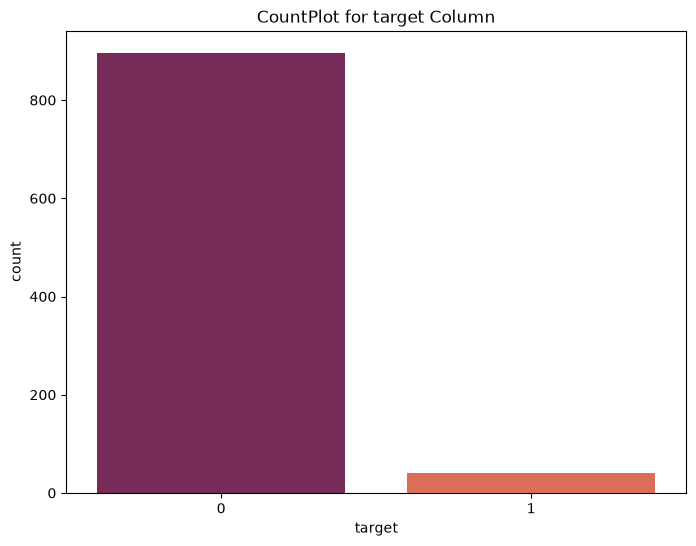

In [10]:
print(df["target"].value_counts())
print("-"*84)
print(df["target"].value_counts(normalize=True)*100)
print("-"*84)

plt.figure(figsize=(8,6))

sns.countplot(df,x="target",palette="rocket",hue="target",legend=False)
plt.title("CountPlot for target Column")
plt.savefig(f"images/CountPlot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

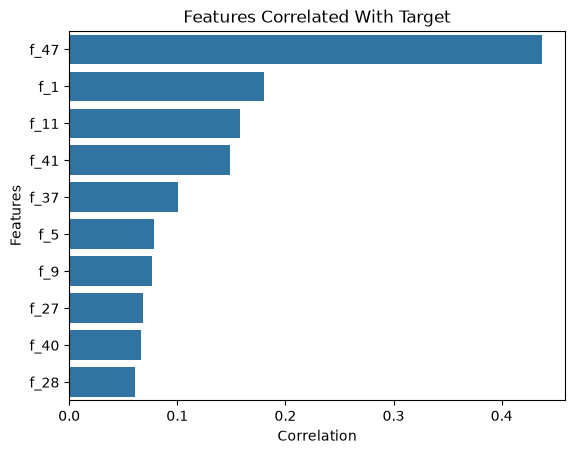

In [11]:
corr = df.corr()["target"].drop("target").abs().sort_values(ascending=False).head(10)

sns.barplot(x=corr.values,y=corr.index)

plt.title("Features Correlated With Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.savefig(f"images/AbsoluteCorralation.png",
        dpi=300,
        bbox_inches="tight")
plt.show()


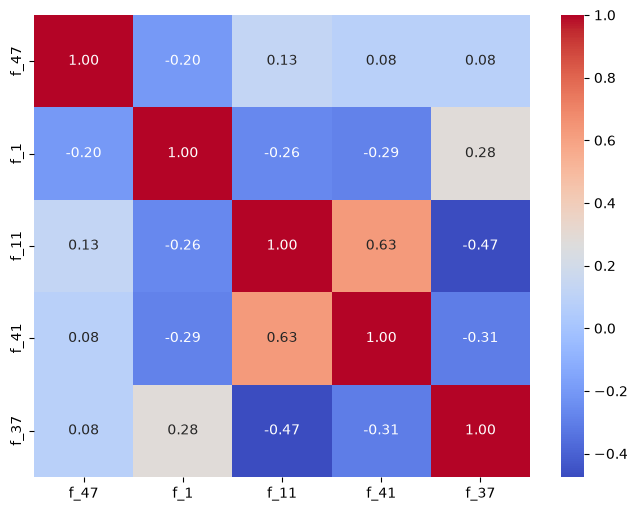

In [12]:
df_corr = df[["f_47","f_1","f_11","f_41","f_37"]]
plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(),fmt=".2f",annot=True,cmap="coolwarm")
plt.savefig(f"images/HeatMap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

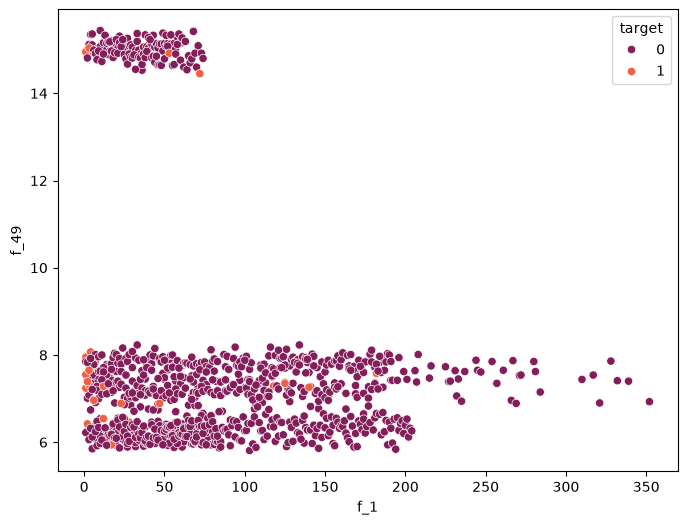

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,x="f_1",y="f_49",hue="target",palette="rocket")
plt.savefig(f"images/ScatterPlot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

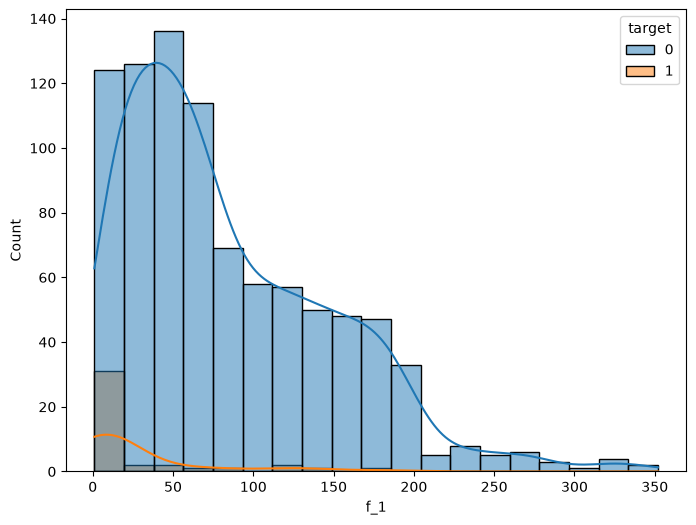

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(df,x="f_1",hue="target",kde=True)
plt.savefig(f"images/HistPlot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [16]:
feature = df.columns.drop("target")
df[feature] = df[feature].replace(0,nan)

In [ ]:
df.isna().sum().sum()

np.int64(3481)

In [18]:
X,y = df.drop("target",axis=1),df["target"]

In [19]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
pipe = Pipeline([("impute",SimpleImputer(strategy="median")),("model",RandomForestClassifier())])

In [21]:
param = [
    {
        "model":[RandomForestClassifier()],
        "model__n_estimators": [100, 150, 200],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },

    {
        "model":[XGBClassifier()],
        "model__n_estimators": [100, 150, 200],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
        "model__min_child_weight": [1, 3, 5]
    }
]

In [22]:
grid = RandomizedSearchCV(pipe,param,n_iter=50,scoring="f1",cv=5,verbose=1,n_jobs=-1)

In [23]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [RandomForestClassifier()], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}, {'model': [XGBClassifier...ree=None, ...)], 'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will 

In [24]:
best = grid.best_estimator_

print(grid.best_score_)
print(grid.best_params_)
print(grid.best_estimator_)

y_pred = best.predict(x_test)
y_prob = best.predict_proba(x_test)[:,1]
y_pred = (y_prob >= 0.3).astype(int)

ac = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
pr = precision_score(y_test,y_pred)
re = recall_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_prob)

p = {
    "accuracy_score":ac*100,
    "f1_score":f1*100,
    "precision_score":pr*100,
    "recall_score":re*100,
    "roc_auc_score":roc*100
}

p = DataFrame(p,index=[""])
p

0.45686868686868676
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0, 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)}
Pipeline(steps=[('impute', SimpleImputer(

,accuracy_score,f1_score,precision_score,recall_score,roc_auc_score
,95.744681,50.0,45.454545,55.555556,97.640118


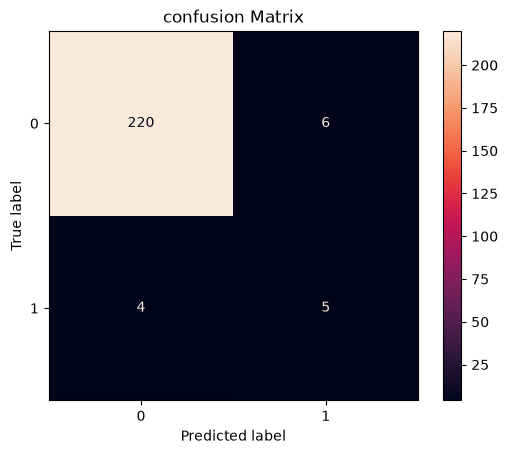

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="rocket")

plt.title("confusion Matrix")
plt.savefig(f"images/ConfusionMatrix.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

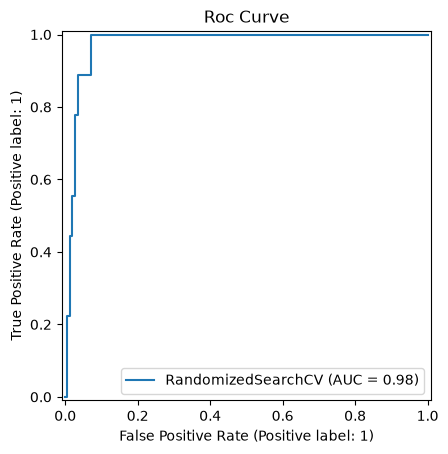

In [26]:
RocCurveDisplay.from_estimator(grid,x_test,y_test)
plt.title("Roc Curve")
plt.savefig(f"images/RocCurve.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [27]:
joblib.dump(grid.best_estimator_,"models/Oil_Spill_model.joblib")
print("model saved")

model saved
